In [ ]:
# Step 01: Import libraries for data analysis, preprocessing, model training, tuning, and visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

In [2]:
# Step 02: Load dataset automatically using raw GitHub link
import pandas as pd

RAW_URL = "https://raw.githubusercontent.com/abir945/AI_ML_LAB/main/CART_ID3/dataset/train.csv"

if "PASTE_YOUR_RAW_GITHUB_CSV_LINK_HERE" in RAW_URL:
    raise ValueError("Please paste your raw GitHub CSV link in RAW_URL before running the notebook.")

df = pd.read_csv(RAW_URL)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (10443, 7)


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34.0,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9.0,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8.0,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29.0,USA,Masters,"C++, Ruby","Spring, Angular",Nov-50,214386
4,7.0,USA,Bachelors,"C#, Rust","React, Express",10-Jan,107584


In [3]:
# Step 03: Basic data exploration - shape, columns, data types, first rows, and last rows

print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

display(df.head())
display(df.tail())

Rows and Columns: (10443, 7)

Column Names:
['experience', 'country', 'education', 'languages', 'frameworks', 'company_size', 'salary_usd']

Data Types:
experience      float64
country          object
education        object
languages        object
frameworks       object
company_size     object
salary_usd        int64
dtype: object


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34.0,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9.0,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8.0,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29.0,USA,Masters,"C++, Ruby","Spring, Angular",Nov-50,214386
4,7.0,USA,Bachelors,"C#, Rust","React, Express",10-Jan,107584


,experience,country,education,languages,frameworks,company_size,salary_usd
10438,34.0,USA,Bachelors,"Ruby, Swift","Django, Angular",1001-5000,154431
10439,NaN,Germany,Masters,"Rust, Java","Django, Angular",201-1000,95968
10440,15.0,USA,Bachelors,"Rust, PHP","Laravel, Express",201-1000,111545
10441,6.0,USA,Bachelors,"Swift, Rust","Express, React",5000+,112681
10442,30.0,Singapore,Masters,"PHP, C++","Ruby on Rails, Ruby on Rails",Nov-50,167996


In [ ]:
# Step 04: Check missing values and duplicate rows

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

print("Missing Value Summary:")
display(missing_table)

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Value Summary:


,Missing Values,Missing Percentage
experience,1,0.009576
country,0,0.000000
education,0,0.000000
languages,0,0.000000
frameworks,0,0.000000
company_size,0,0.000000
salary_usd,0,0.000000



Duplicate Rows: 0


In [ ]:
# Step 05: Summary statistics for numerical and categorical columns

print("Numerical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include="object"))

Numerical Summary:


,experience,salary_usd
count,10442.000000,10443.000000
mean,19.878472,131736.778129
std,11.815038,46195.765324
min,0.000000,12064.000000
25%,10.000000,98291.500000
50%,20.000000,131291.000000
75%,30.000000,164217.500000
max,40.000000,273362.000000



Categorical Summary:


,country,education,languages,frameworks,company_size
count,10443,10443,10443,10443,10443
unique,10,5,100,100,6
top,USA,Bachelors,"PHP, PHP","Laravel, Vue",51-200
freq,4102,5242,139,133,1773


In [ ]:
# Step 06: Clean obvious category formatting problems
# In this dataset, company_size has Excel/date-like values:
# '10-Jan' means '1-10' and 'Nov-50' means '11-50'

df = df.copy()

if "company_size" in df.columns:
    df["company_size"] = df["company_size"].replace({
        "10-Jan": "1-10",
        "Nov-50": "11-50"
    })

print("Company size values after cleaning:")
print(df["company_size"].unique())

Company size values after cleaning:
['201-1000' '5000+' '11-50' '1-10' '51-200' '1001-5000']


In [ ]:
# Step 07: Create classification target from salary_usd
# Decision Tree assignment is classification-based, so salary_usd is converted into a binary target.
# high_salary = 1 means salary is greater than or equal to median salary.
# high_salary = 0 means salary is below median salary.

target_column = "salary_usd"

median_salary = df[target_column].median()
df["high_salary"] = (df[target_column] >= median_salary).astype(int)

print("Median Salary:", median_salary)
print("\nTarget Distribution:")
print(df["high_salary"].value_counts())
print("\nTarget Percentage:")
print(df["high_salary"].value_counts(normalize=True) * 100)

Median Salary: 131291.0

Target Distribution:
high_salary
1    5222
0    5221
Name: count, dtype: int64

Target Percentage:
high_salary
1    50.004788
0    49.995212
Name: proportion, dtype: float64


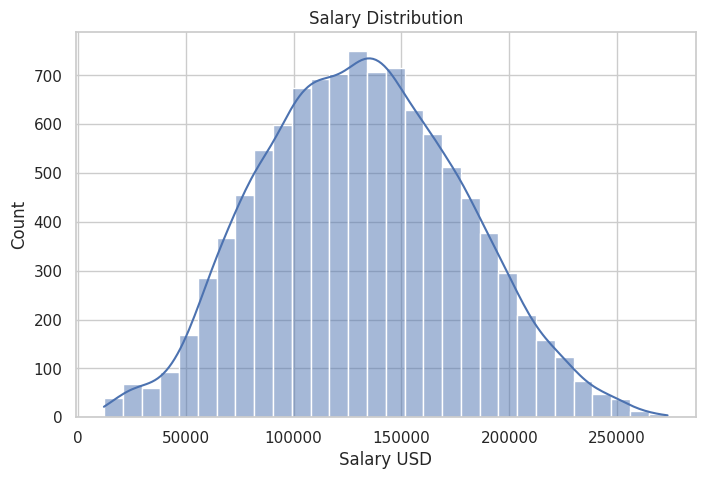

In [ ]:
# Step 08: Salary distribution plot

plt.figure(figsize=(8, 5))
sns.histplot(df["salary_usd"], bins=30, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary USD")
plt.ylabel("Count")
plt.show()

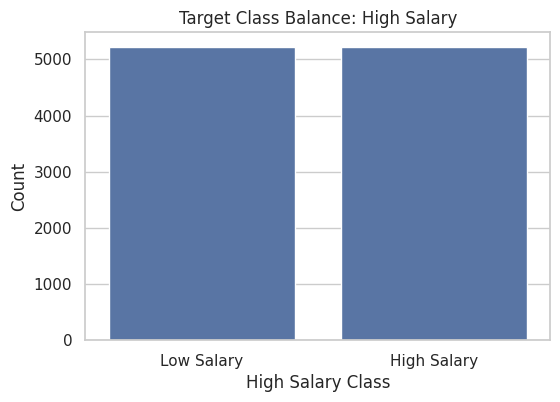

In [ ]:
# Step 09: Target class balance plot

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="high_salary")
plt.title("Target Class Balance: High Salary")
plt.xlabel("High Salary Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Low Salary", "High Salary"])
plt.show()

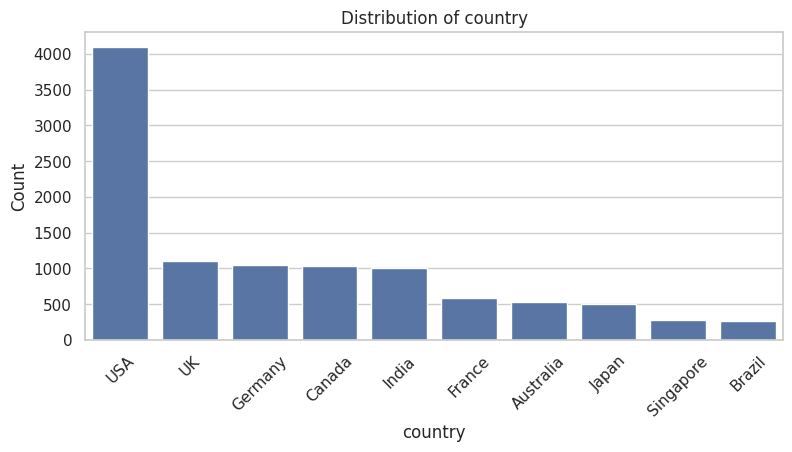

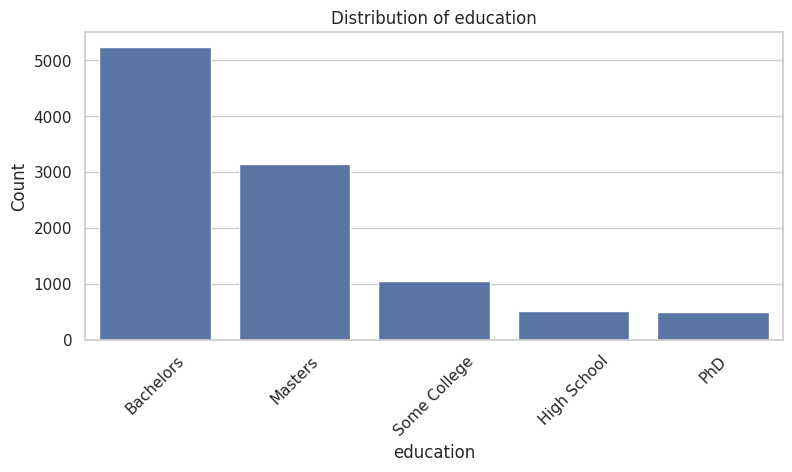

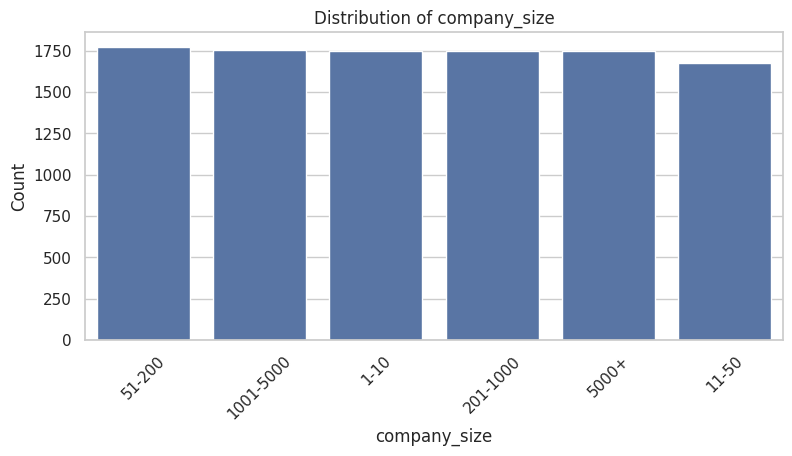

In [ ]:
# Step 10: Explore important categorical columns with count plots
# These plots help understand the most common countries, education levels, and company sizes.

categorical_columns_to_plot = ["country", "education", "company_size"]

for col in categorical_columns_to_plot:
    if col in df.columns:
        plt.figure(figsize=(9, 4))
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, order=order)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

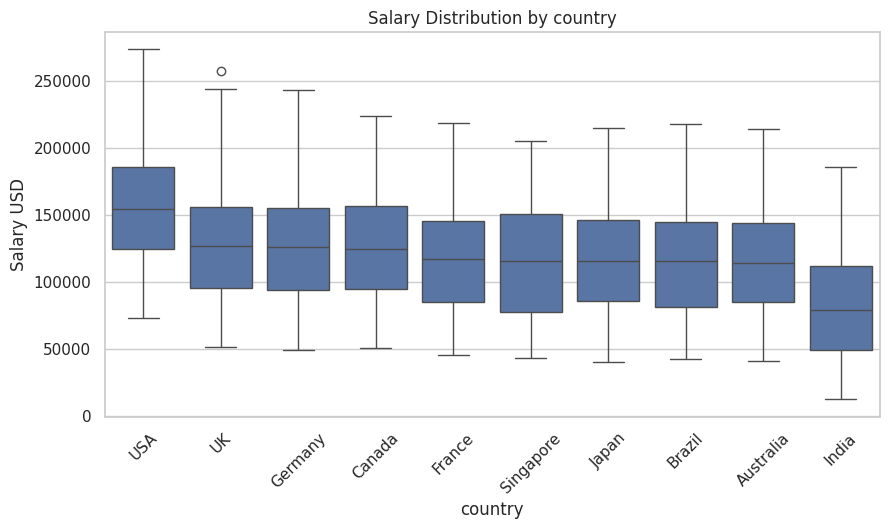

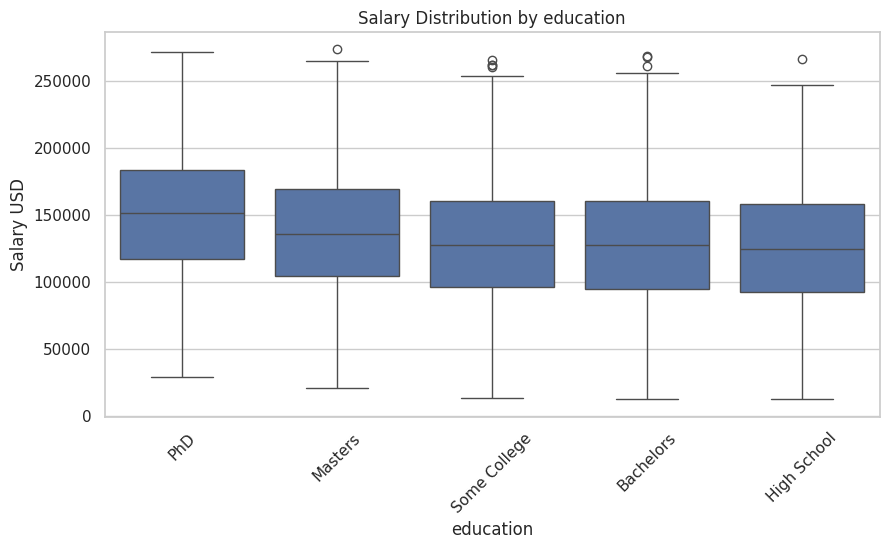

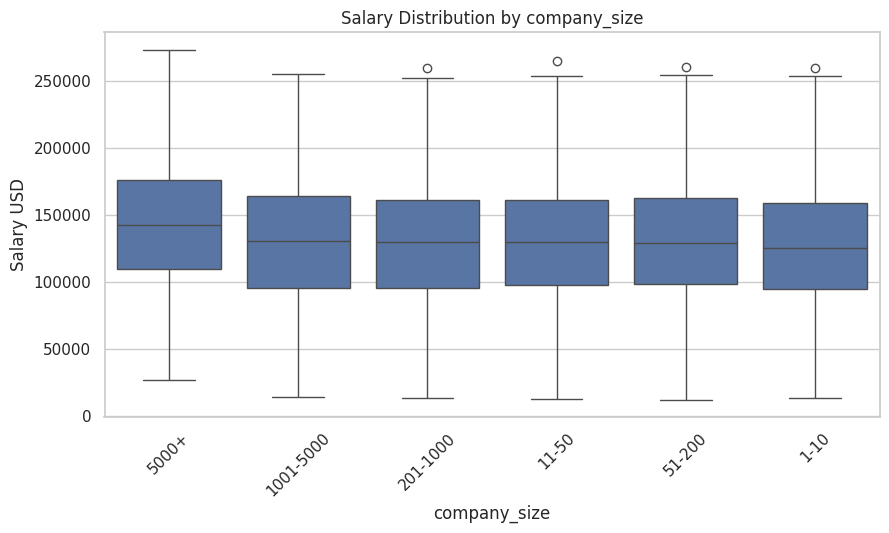

In [ ]:
# Step 11: Explore salary by categorical features using boxplots

boxplot_columns = ["country", "education", "company_size"]

for col in boxplot_columns:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        order = df.groupby(col)["salary_usd"].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x=col, y="salary_usd", order=order)
        plt.title(f"Salary Distribution by {col}")
        plt.xlabel(col)
        plt.ylabel("Salary USD")
        plt.xticks(rotation=45)
        plt.show()

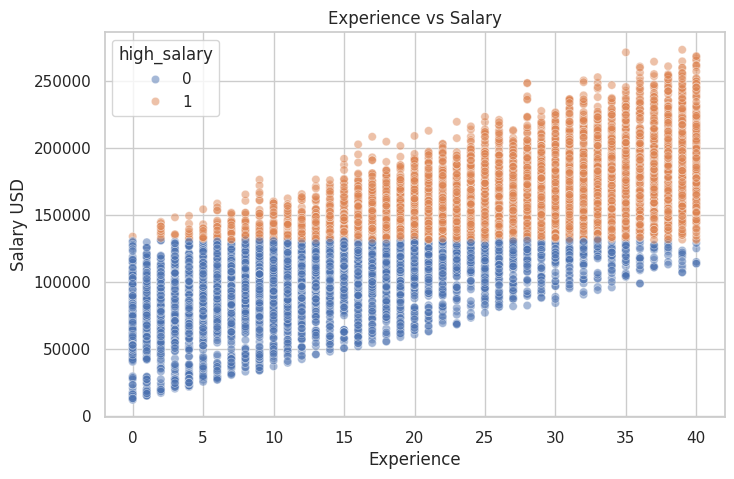

In [ ]:
# Step 12: Explore relationship between experience and salary

if "experience" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x="experience", y="salary_usd", hue="high_salary", alpha=0.5)
    plt.title("Experience vs Salary")
    plt.xlabel("Experience")
    plt.ylabel("Salary USD")
    plt.show()

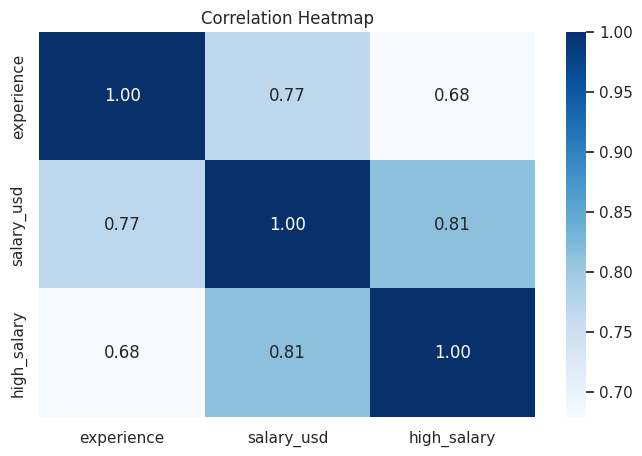

In [ ]:
# Step 13: Correlation heatmap for numerical columns

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Step 14: Feature engineering for multi-value columns
# languages and frameworks contain comma-separated values.
# We split them into separate multi-hot encoded columns.

def split_multivalue_columns(dataframe, columns):
    data = dataframe.copy()

    for col in columns:
        if col in data.columns:
            dummies = data[col].fillna("Unknown").str.get_dummies(sep=", ")
            dummies = dummies.add_prefix(col + "_")
            data = data.drop(columns=[col])
            data = pd.concat([data, dummies], axis=1)

    return data

df_model = split_multivalue_columns(df, ["languages", "frameworks"])

print("Shape before feature engineering:", df.shape)
print("Shape after feature engineering:", df_model.shape)
df_model.head()

Shape before feature engineering: (10443, 8)
Shape after feature engineering: (10443, 26)


,experience,country,education,company_size,salary_usd,high_salary,languages_C#,languages_C++,languages_Go,languages_Java,...,frameworks_ASP.NET,frameworks_Angular,frameworks_Django,frameworks_Express,frameworks_Flask,frameworks_Laravel,frameworks_React,frameworks_Ruby on Rails,frameworks_Spring,frameworks_Vue
0,34.0,Germany,Masters,201-1000,172292,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,9.0,UK,Masters,201-1000,82311,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
2,8.0,USA,Some College,5000+,109637,0,0,1,1,0,...,0,0,0,0,0,0,1,0,0,1
3,29.0,USA,Masters,11-50,214386,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
4,7.0,USA,Bachelors,1-10,107584,0,1,0,0,0,...,0,0,0,1,0,0,1,0,0,0


In [ ]:
# Step 15: Define features X and target y
# salary_usd is dropped because it was used to create the classification target.

X = df_model.drop(columns=["salary_usd", "high_salary"])
y = df_model["high_salary"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget class count:")
print(y.value_counts())

Feature shape: (10443, 24)
Target shape: (10443,)

Target class count:
high_salary
1    5222
0    5221
Name: count, dtype: int64


In [ ]:
# Step 16: Split data into train and test sets
# Stratify keeps class distribution similar in train and test sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (8354, 24)
Testing shape: (2089, 24)


In [ ]:
# Step 17: Create preprocessing pipeline
# Numerical features: fill missing values with median and scale values.
# Categorical features: fill missing values with most frequent value and apply One-Hot Encoding.

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['experience', 'languages_C#', 'languages_C++', 'languages_Go', 'languages_Java', 'languages_JavaScript', 'languages_PHP', 'languages_Python', 'languages_Ruby', 'languages_Rust', 'languages_Swift', 'frameworks_ASP.NET', 'frameworks_Angular', 'frameworks_Django', 'frameworks_Express', 'frameworks_Flask', 'frameworks_Laravel', 'frameworks_React', 'frameworks_Ruby on Rails', 'frameworks_Spring', 'frameworks_Vue']
Categorical features: ['country', 'education', 'company_size']


In [ ]:
# Step 18: Build CART model pipeline using Gini criterion

cart_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        random_state=42,
        class_weight="balanced"
    ))
])

In [ ]:
# Step 19: Build ID3 model pipeline using Entropy criterion

id3_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",
        random_state=42,
        class_weight="balanced"
    ))
])

In [ ]:
# Step 20: Tune CART and ID3 models using Cross-Validation
# We tune max_depth and min_samples_split as required in the assignment.
# n_jobs=1 is used to avoid Colab/GitHub joblib multiprocessing issues.

param_grid = {
    "classifier__max_depth": [3, 5, 7, 10],
    "classifier__min_samples_split": [2, 10, 20]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cart_search = GridSearchCV(
    estimator=cart_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1
)

id3_search = GridSearchCV(
    estimator=id3_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1
)

cart_search.fit(X_train, y_train)
id3_search.fit(X_train, y_train)

print("Best CART Parameters:", cart_search.best_params_)
print("Best CART CV ROC-AUC:", cart_search.best_score_)

print("\nBest ID3 Parameters:", id3_search.best_params_)
print("Best ID3 CV ROC-AUC:", id3_search.best_score_)

Best CART Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 20}
Best CART CV ROC-AUC: 0.9543138165543468

Best ID3 Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 20}
Best ID3 CV ROC-AUC: 0.955908282490566


In [ ]:
# Step 21: Evaluate optimized CART and ID3 models on the test set

best_cart = cart_search.best_estimator_
best_id3 = id3_search.best_estimator_

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }

cart_metrics = evaluate_model(best_cart, X_test, y_test)
id3_metrics = evaluate_model(best_id3, X_test, y_test)

metrics_df = pd.DataFrame([cart_metrics, id3_metrics], index=["CART (Gini)", "ID3 (Entropy)"])

print("Test Set Evaluation Metrics:")
display(metrics_df)

Test Set Evaluation Metrics:


,Accuracy,Precision,Recall,F1,AUC
CART (Gini),0.866922,0.885427,0.843062,0.863725,0.948768
ID3 (Entropy),0.865007,0.889683,0.833493,0.860672,0.947312


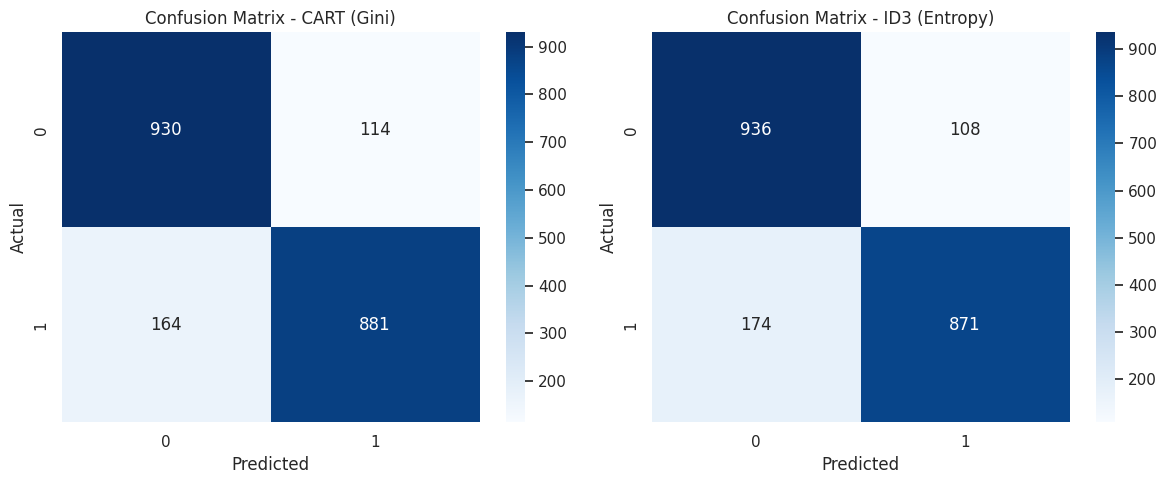

In [ ]:
# Step 22: Confusion Matrix Heatmap - CART vs ID3 in 2x1 comparison format

models = {
    "CART (Gini)": best_cart,
    "ID3 (Entropy)": best_id3
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

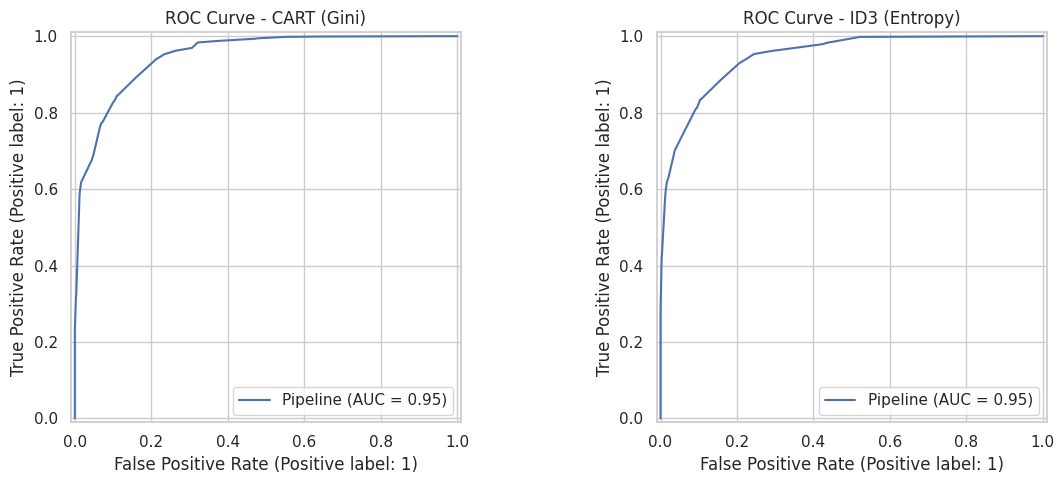

In [ ]:
# Step 23: ROC Curve Plot - CART vs ID3 in 2x1 comparison format

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, models.items()):
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
    ax.set_title(f"ROC Curve - {name}")

plt.tight_layout()
plt.show()

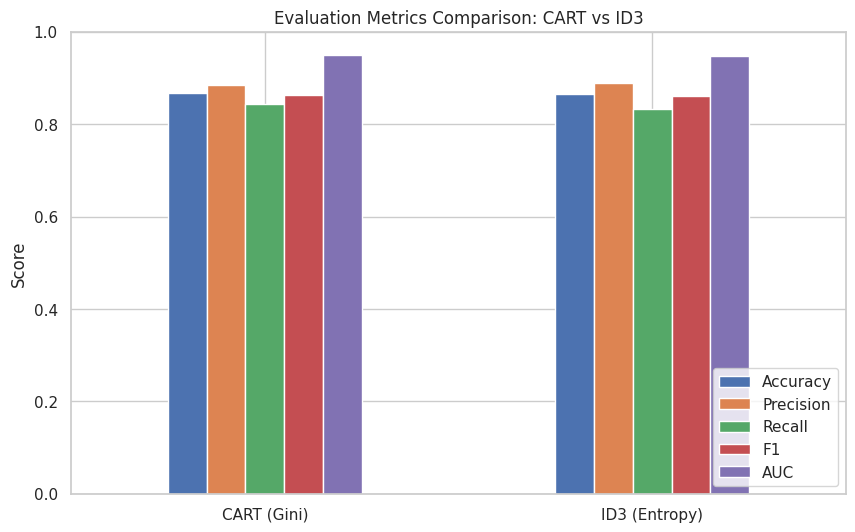

In [ ]:
# Step 24: Evaluation Metrics Bar Chart - Combined comparison of CART and ID3

metrics_df.plot(kind="bar", figsize=(10, 6))
plt.title("Evaluation Metrics Comparison: CART vs ID3")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Step 25: Prepare 2D PCA data for Decision Boundary visualization
# Decision boundary needs 2D features, so we transform preprocessed data into 2 PCA components.

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_processed)
X_test_2d = pca.transform(X_test_processed)

print("2D train shape:", X_train_2d.shape)
print("2D test shape:", X_test_2d.shape)

2D train shape: (8354, 2)
2D test shape: (2089, 2)


In [ ]:
# Step 26: Train 2D CART and ID3 models using best hyperparameters
# These 2D models are only for clean decision boundary visualization.

cart_best_params = cart_search.best_params_
id3_best_params = id3_search.best_params_

cart_2d = DecisionTreeClassifier(
    criterion="gini",
    max_depth=cart_best_params["classifier__max_depth"],
    min_samples_split=cart_best_params["classifier__min_samples_split"],
    random_state=42,
    class_weight="balanced"
)

id3_2d = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=id3_best_params["classifier__max_depth"],
    min_samples_split=id3_best_params["classifier__min_samples_split"],
    random_state=42,
    class_weight="balanced"
)

cart_2d.fit(X_train_2d, y_train)
id3_2d.fit(X_train_2d, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, min_samples_split=20, random_state=42)

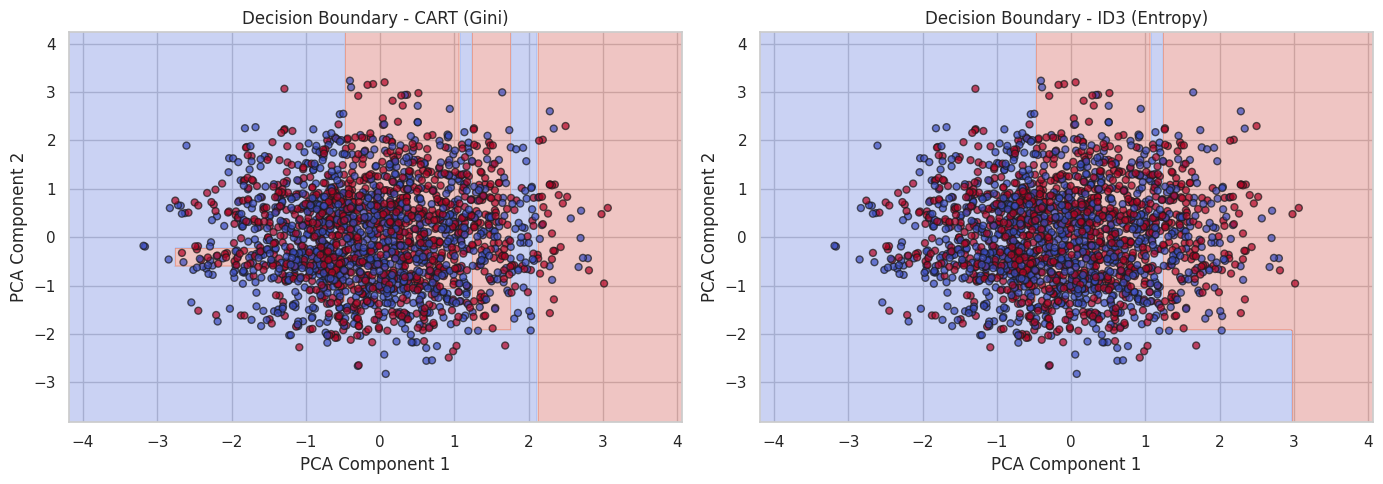

In [ ]:
# Step 27: Decision Boundary Plot - CART vs ID3 in 2x1 comparison format

def plot_decision_boundary(ax, model, X_2d, y, title):
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolor="k",
        s=25,
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary(axes[0], cart_2d, X_test_2d, y_test, "Decision Boundary - CART (Gini)")
plot_decision_boundary(axes[1], id3_2d, X_test_2d, y_test, "Decision Boundary - ID3 (Entropy)")

plt.tight_layout()
plt.show()

In [ ]:
# Step 28: Get feature names after preprocessing for tree visualization

ohe = best_cart.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]

encoded_cat_features = []
if len(categorical_features) > 0:
    encoded_cat_features = ohe.get_feature_names_out(categorical_features).tolist()

feature_names = numeric_features + encoded_cat_features

print("Total transformed features:", len(feature_names))
print(feature_names[:20])

Total transformed features: 42
['experience', 'languages_C#', 'languages_C++', 'languages_Go', 'languages_Java', 'languages_JavaScript', 'languages_PHP', 'languages_Python', 'languages_Ruby', 'languages_Rust', 'languages_Swift', 'frameworks_ASP.NET', 'frameworks_Angular', 'frameworks_Django', 'frameworks_Express', 'frameworks_Flask', 'frameworks_Laravel', 'frameworks_React', 'frameworks_Ruby on Rails', 'frameworks_Spring']


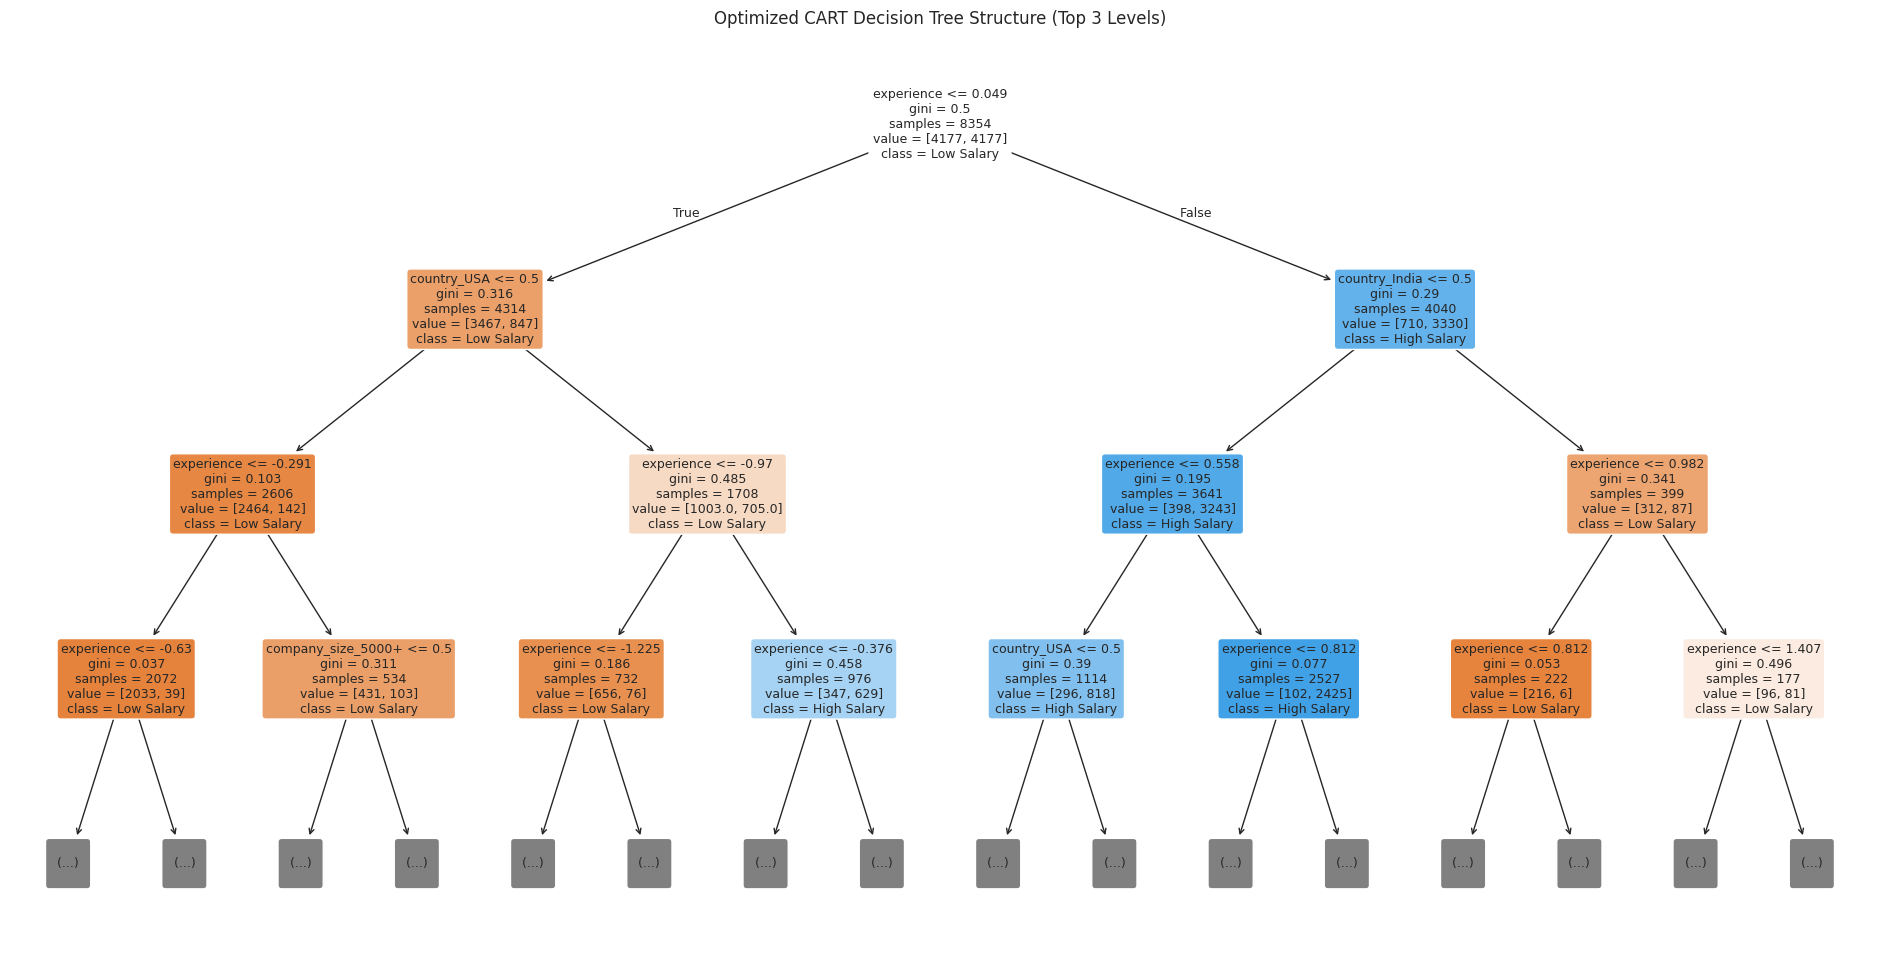

In [ ]:
# Step 29: Visualize optimized Decision Tree structure
# The tree can be very large, so max_depth=3 is used only for readable visualization of the optimized CART tree.

cart_tree_model = best_cart.named_steps["classifier"]

plt.figure(figsize=(24, 12))
plot_tree(
    cart_tree_model,
    feature_names=feature_names,
    class_names=["Low Salary", "High Salary"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Optimized CART Decision Tree Structure (Top 3 Levels)")
plt.show()

In [ ]:
# Step 30: Show final comparison result in a simple table

best_model_name = metrics_df["AUC"].idxmax()

print("Final Model Comparison:")
display(metrics_df)

print(f"\nBest model based on Test AUC: {best_model_name}")
print("\nConclusion:")
print("Both CART and ID3 Decision Trees were trained and tuned using Cross-Validation.")
print("The final model was selected by comparing Accuracy, Precision, Recall, F1-score, and AUC on the test set.")

Final Model Comparison:


,Accuracy,Precision,Recall,F1,AUC
CART (Gini),0.866922,0.885427,0.843062,0.863725,0.948768
ID3 (Entropy),0.865007,0.889683,0.833493,0.860672,0.947312



Best model based on Test AUC: CART (Gini)

Conclusion:
Both CART and ID3 Decision Trees were trained and tuned using Cross-Validation.
The final model was selected by comparing Accuracy, Precision, Recall, F1-score, and AUC on the test set.


In [ ]:
## Project Summary: Decision Tree Assignment - CART vs ID3

This project implemented a complete machine learning workflow to classify salaries as 'high' or 'low' using Decision Tree algorithms (CART and ID3).

**1. Data Loading and Initial Exploration:**
* The dataset was loaded from a raw GitHub CSV link, containing information about developer experience, country, education, languages, frameworks, company size, and salary.
* Initial checks confirmed the dataset shape `(10443, 7)` and data types. Missing values were minimal (only one in 'experience'). There were no duplicate rows.
* Basic descriptive statistics for numerical and categorical features were examined.

**2. Data Preprocessing and Feature Engineering:**
* The `company_size` column had inconsistent formatting ('10-Jan', 'Nov-50'), which was cleaned to '1-10' and '11-50' respectively.
* The `salary_usd` column, a numerical target, was converted into a binary classification target called `high_salary`. A salary was classified as 'high' (1) if it was greater than or equal to the median salary (`131291.0`), and 'low' (0) otherwise. This resulted in a nearly balanced target distribution.
* Multi-value categorical columns (`languages`, `frameworks`) were transformed using one-hot encoding to create new binary features, significantly increasing the feature space.

**3. Exploratory Data Analysis (EDA) - Visualizations:**
* Histograms showed the distribution of salaries.
* Count plots illustrated the distribution of key categorical features like `country`, `education`, and `company_size`.
* Box plots displayed salary distributions across different categories, revealing insights into how features influence salary.
* A scatter plot visualized the relationship between `experience` and `salary_usd`, colored by `high_salary`.
* A correlation heatmap showed relationships between numerical features.

**4. Model Training and Hyperparameter Tuning:**
* The dataset was split into training (80%) and testing (20%) sets, ensuring stratified sampling to maintain target class distribution.
* A preprocessing pipeline was established:
    * Numerical features were imputed with the median and scaled using `StandardScaler`.
    * Categorical features were imputed with the most frequent value and encoded using `OneHotEncoder`.
* Two Decision Tree models were built:
    * **CART (Classification and Regression Trees)** using the Gini impurity criterion.
    * **ID3 (Iterative Dichotomiser 3)** using the Entropy criterion.
* Both models were integrated into pipelines with the preprocessor.
* Hyperparameter tuning for both models (`max_depth` and `min_samples_split`) was performed using `GridSearchCV` with `StratifiedKFold` (3 splits) and `roc_auc` as the scoring metric.
    * Best CART Parameters: `{'classifier__max_depth': 5, 'classifier__min_samples_split': 20}` with a CV ROC-AUC of `0.954`.
    * Best ID3 Parameters: `{'classifier__max_depth': 5, 'classifier__min_samples_split': 20}` with a CV ROC-AUC of `0.956`.

**5. Model Evaluation and Visualization:**
* The optimized CART and ID3 models were evaluated on the unseen test set using various metrics:
    * **CART (Gini):** Accuracy: `0.867`, Precision: `0.885`, Recall: `0.843`, F1: `0.864`, AUC: `0.949`.
    * **ID3 (Entropy):** Accuracy: `0.865`, Precision: `0.890`, Recall: `0.833`, F1: `0.861`, AUC: `0.947`.
* Visualizations included:
    * **Confusion Matrices:** Displayed true positives, true negatives, false positives, and false negatives for both models.
    * **ROC Curves:** Plotted the Receiver Operating Characteristic curves, highlighting the trade-off between true positive rate and false positive rate.
    * **Evaluation Metrics Bar Chart:** A combined bar chart for easy comparison of Accuracy, Precision, Recall, F1-score, and AUC between CART and ID3.
* For decision boundary visualization, the preprocessed data was reduced to two principal components using PCA, and separate 2D Decision Tree models were trained and visualized.
* A visualization of the optimized CART Decision Tree structure (up to max_depth=3) was provided to illustrate the decision-making process.

**6. Conclusion:**
* Both CART and ID3 Decision Tree models were successfully trained, tuned, and evaluated.
* Based on the test set AUC score, **CART (Gini)** was identified as the marginally better model for this classification task. The performance metrics for both models were very similar, indicating robust performance.